# Load and Explore Sum-of-Checks

Load the public [BrachioLab/sum-of-checks dataset](https://huggingface.co/datasets/BrachioLab/sum-of-checks): 53 corrected Endoscapes images (4 few-shot / 49 dev) and 60 SAGES images (6 few-shot / 54 dev), with original CVS labels and 19 human-labeled rubric checks.

**Development data, not expert ground truth.** The rubric labels were provided by an ML PhD student trained by a surgeon. Use these annotations as development data, not as expert surgical ground truth. This caveat concerns the added rubric annotations; the original CVS labels are retained separately from their source datasets.

The examples below are saved as PNG figures and plain-text output so they are visible on GitHub. No HTML or widgets are required.

Install dependencies with `pip install datasets huggingface_hub matplotlib Pillow` (or `pip install -r requirements-hf.txt` from the repository root).

In [1]:
import json
import os
import tempfile
import textwrap
from pathlib import Path

# Keep the image-transfer cache writable on shared machines.
os.environ.setdefault("HF_XET_CACHE", str(Path(tempfile.gettempdir()) / "sumofchecks-hf-xet"))

import matplotlib.pyplot as plt
from datasets import load_dataset, disable_progress_bars
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import disable_progress_bars as disable_hub_progress_bars
from matplotlib_inline.backend_inline import set_matplotlib_formats

get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("png")
disable_progress_bars()
disable_hub_progress_bars()

REPO_ID = "BrachioLab/sum-of-checks"
REVISION = "f4053d297158514a56a50100f10553e6180cca56"
CRITERIA = ("c1", "c2", "c3")


In [2]:
# token=False loads this public dataset without requiring login credentials.
splits_by_source = {
    source: load_dataset(REPO_ID, source, revision=REVISION, token=False)
    for source in ("endoscapes", "sages")
}
datasets_by_source = {source: splits["dev"] for source, splits in splits_by_source.items()}
few_shot_by_source = {source: splits["few_shot"] for source, splits in splits_by_source.items()}
rubric_path = hf_hub_download(
    REPO_ID, "rubrics/cvs_rubrics_v3.json", repo_type="dataset",
    revision=REVISION, token=False,
)
rubrics = json.loads(Path(rubric_path).read_text())

expected_counts = {"endoscapes": {"few_shot": 4, "dev": 49}, "sages": {"few_shot": 6, "dev": 54}}
for source, splits in splits_by_source.items():
    assert {split: len(ds) for split, ds in splits.items()} == expected_counts[source]
    assert set(splits) == {"few_shot", "dev"}
    for field in ("example_id", "image_sha256"):
        assert not set(splits["few_shot"][field]) & set(splits["dev"][field])
    assert list(splits["few_shot"]["few_shot_order"]) == list(range(expected_counts[source]["few_shot"]))
    assert all(splits["few_shot"]["is_few_shot"])
    assert not any(splits["dev"]["is_few_shot"])
    print(f"{source}: " + ", ".join(f"{split}={len(ds)}" for split, ds in splits.items()))
    print(f"  Original source splits: {sorted(set(splits['dev']['source_split']))}")
    for ds in splits.values():
        assert set(ds['annotation_rubric_version']) == {"cvs_rubrics_v3"}
        assert set(ds['rubric_version']) == {"cvs_rubrics_v3"}
    print(f"  Annotation rubric: {sorted(set(splits['dev']['annotation_rubric_version']))}")
print("No shared image IDs or image checksums between few_shot and dev.")
print(f"Rubric v3: {sum(len(block['items']) for block in rubrics['criteria'].values())} checks")
print(f"Revision: {REVISION}")


endoscapes: few_shot=4, dev=49
  Original source splits: ['val']
  Annotation rubric: ['cvs_rubrics_v3']
sages: few_shot=6, dev=54
  Original source splits: ['train']
  Annotation rubric: ['cvs_rubrics_v3']
No shared image IDs or image checksums between few_shot and dev.
Rubric v3: 19 checks
Revision: f4053d297158514a56a50100f10553e6180cca56


## Fields and Provenance

`image` is a decoded PIL image from the original embedded image bytes. `cvs_labels` preserves Endoscapes's continuous labels or SAGES's majority-vote labels; `cvs_binary_labels` uses a threshold greater than 0.5. `cvs_rater_labels` preserves the three individual SAGES votes. The complete original source label record is available in `original_cvs_annotation_json`.

`rubric_labels` contains yes/no/uncertain answers keyed by check IDs. Both Endoscapes and SAGES use rubric v3 for `rubric_version` and `annotation_rubric_version`, following the dataset maintainer's version attribution. `rubrics/cvs_rubrics_v3.json` provides check text and weights. The archived source-file version is preserved separately in `source_annotation_rubric_version` for traceability; legacy Endoscapes filenames still contain v1. This metadata update did not change any rubric answers.

The gallery selects distinct examples emphasizing yes, no, and uncertain rubric answers for each source. Counts in the titles describe all 19 checks. The detailed examples favor a balanced mix of answer types. These are illustrative development examples, not a representative sample or the paper's 791-frame evaluation split.

Both sources have separate `few_shot` and `dev` splits. All galleries and detailed examples above the few-shot section use only `dev`. Splits are image-disjoint, not video-disjoint. `is_few_shot` applies to both sources; the older `is_paper_few_shot` field remains Endoscapes-only.


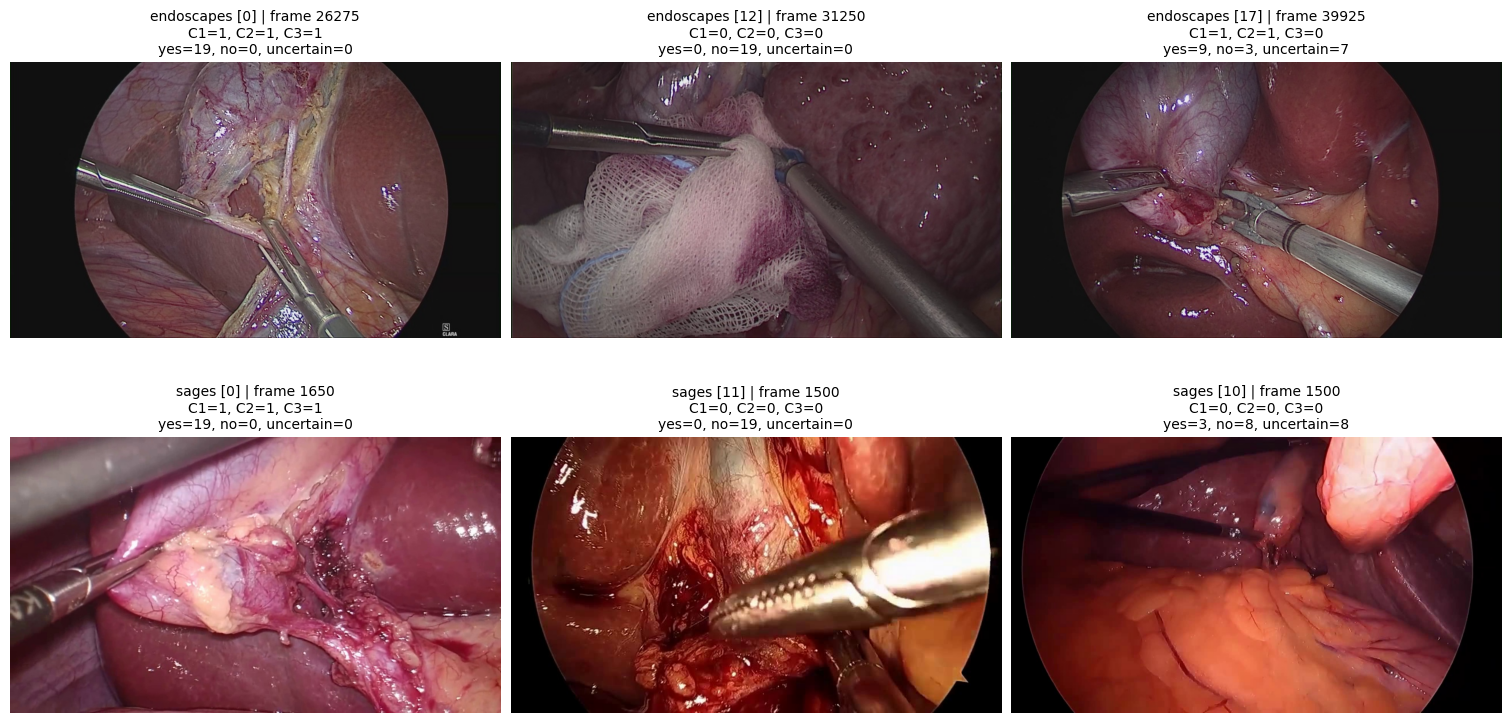

In [3]:
ANSWERS = ("yes", "no", "uncertain")

def answer_counts(labels):
    return tuple(list(labels.values()).count(answer) for answer in ANSWERS)

def diverse_indices(dataset):
    counts = [answer_counts(labels) for labels in dataset["rubric_labels"]]
    selected = []
    for answer_index in range(len(ANSWERS)):
        remaining = [i for i in range(len(dataset)) if i not in selected]
        if not remaining:
            break
        selected.append(max(remaining, key=lambda i: counts[i][answer_index]))
    return selected

def mixed_index(dataset):
    counts = [answer_counts(labels) for labels in dataset["rubric_labels"]]
    return max(range(len(dataset)), key=lambda i: (
        sum(n > 0 for n in counts[i]), min(counts[i]), -max(counts[i]),
    ))

gallery_indices = {source: diverse_indices(ds) for source, ds in datasets_by_source.items()}
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), layout="constrained")
for row_index, (source, dataset) in enumerate(datasets_by_source.items()):
    for column_index, ax in enumerate(axes[row_index]):
        ax.axis("off")
        indices = gallery_indices[source]
        if column_index >= len(indices):
            continue
        index = indices[column_index]
        example = dataset[index]
        labels = ", ".join(f"{c.upper()}={example['cvs_binary_labels'][c]}" for c in CRITERIA)
        counts = answer_counts(example["rubric_labels"])
        answers = ", ".join(f"{answer}={n}" for answer, n in zip(ANSWERS, counts))
        ax.imshow(example["image"])
        ax.set_title(
            f"{source} [{index}] | frame {example['frame_id']}\n{labels}\n{answers}",
            fontsize=10,
        )
plt.show()


## Inspect an Example

Each example below shows the image, original CVS labels, individual votes when available, and all 19 rubric answers alongside their v3 definitions. The weighted check score is computed from the surgeon-trained ML PhD student's rubric annotations; it is neither a model prediction nor expert ground truth.

Change the source and row index in the last two cells to inspect other examples.

In [4]:
def show_example(source, index):
    example = datasets_by_source[source][index]
    fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
    ax.imshow(example["image"])
    ax.axis("off")
    ax.set_title(f"{source} [{index}] | frame {example['frame_id']}", fontsize=12)
    plt.show()

    print(f"Example: {example['example_id']}")
    print(f"Image: {example['image_filename']} ({example['width']} x {example['height']})")
    print(f"Original CVS labels: {example['cvs_labels']}")
    print(f"Binary CVS labels:   {example['cvs_binary_labels']}")
    if any(example["cvs_rater_labels"].values()):
        print(f"Original SAGES votes (rater1, rater2, rater3): {example['cvs_rater_labels']}")
    print(f"CVS labels recorded during rubric annotation: {example['annotation_cvs_labels']}")
    print(f"Annotation rubric: {example['annotation_rubric_version']}")
    print(f"Bundled rubric: {example['rubric_version']}")
    print(f"Paper few-shot example: {example['is_paper_few_shot']}")

    for criterion, block in rubrics["criteria"].items():
        score = sum(
            item["weight"] * (example["rubric_labels"][item["id"]] == "yes")
            for item in block["items"]
        )
        print(f"\n{criterion}: weighted human-check score = {score:.2f} (yes=1, no/uncertain=0)")
        for item in block["items"]:
            answer = example["rubric_labels"][item["id"]]
            prefix = f"  {item['id']:5s} {answer:9s} w={item['weight']:.1f}  "
            print(textwrap.fill(prefix + item["text"], width=110, subsequent_indent=" " * len(prefix)))
    if example["annotation_notes"]:
        print("\nAnnotation notes:")
        print(textwrap.fill(example["annotation_notes"], width=110))


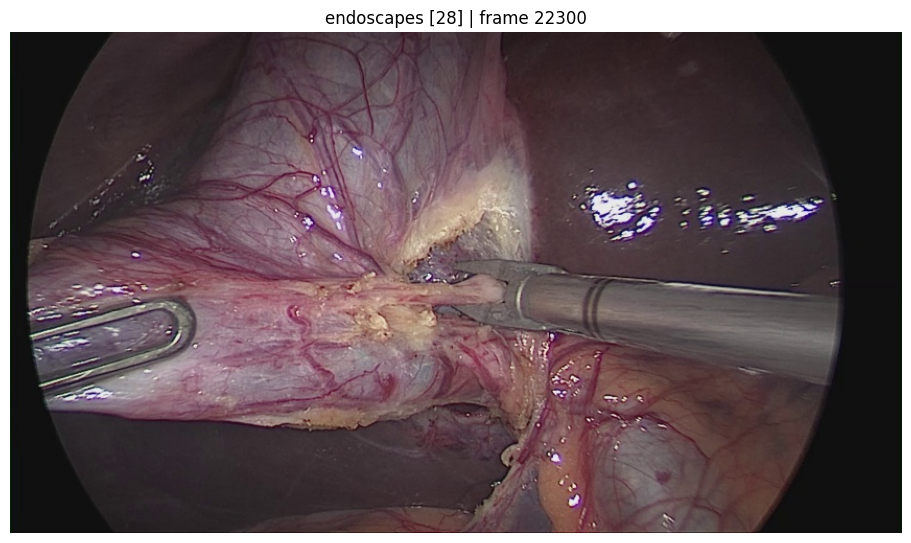

Example: endoscapes/val/148/22300
Image: 148_22300.jpg (854 x 480)
Original CVS labels: {'c1': 0.3333333333333333, 'c2': 0.0, 'c3': 0.6666666666666666}
Binary CVS labels:   {'c1': 0, 'c2': 0, 'c3': 1}
CVS labels recorded during rubric annotation: {'c1': 0.3333333333333333, 'c2': 0.0, 'c3': 0.6666666666666666}
Annotation rubric: cvs_rubrics_v3
Bundled rubric: cvs_rubrics_v3
Paper few-shot example: False

C1: weighted human-check score = 0.10 (yes=1, no/uncertain=0)
  C1-1  no        w=0.1  The gallbladder neck (infundibulum) region is clearly visible and in-frame.
  C1-2  no        w=0.3  There are exactly two tubular attachment tracks entering the gallbladder wall.
  C1-3  uncertain w=0.3  The two tubular structures are visually distinguishable from each other at the
                         gallbladder entry.
  C1-4  uncertain w=0.1  The gallbladder entry site is sufficiently exposed that no additional tubular
                         structure could plausibly be hidden.
  C1-5  yes  

In [5]:
show_example("endoscapes", mixed_index(datasets_by_source["endoscapes"]))

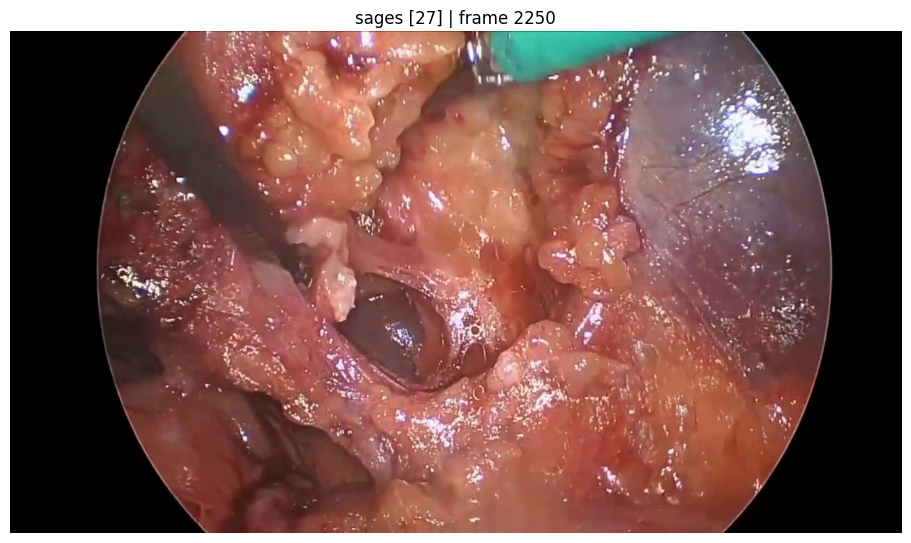

Example: sages/train/e6093fb5-236f-4856-8321-3749229eabf9/2250
Image: frame_002250.jpg (1280 x 720)
Original CVS labels: {'c1': 0.0, 'c2': 1.0, 'c3': 0.0}
Binary CVS labels:   {'c1': 0, 'c2': 1, 'c3': 0}
Original SAGES votes (rater1, rater2, rater3): {'c1': [0, 0, 1], 'c2': [0, 1, 1], 'c3': [0, 0, 1]}
CVS labels recorded during rubric annotation: {'c1': 0.0, 'c2': 1.0, 'c3': 0.0}
Annotation rubric: cvs_rubrics_v3
Bundled rubric: cvs_rubrics_v3
Paper few-shot example: False

C1: weighted human-check score = 0.30 (yes=1, no/uncertain=0)
  C1-1  yes       w=0.1  The gallbladder neck (infundibulum) region is clearly visible and in-frame.
  C1-2  uncertain w=0.3  There are exactly two tubular attachment tracks entering the gallbladder wall.
  C1-3  no        w=0.3  The two tubular structures are visually distinguishable from each other at the
                         gallbladder entry.
  C1-4  no        w=0.1  The gallbladder entry site is sufficiently exposed that no additional tubular
   

In [6]:
show_example("sages", mixed_index(datasets_by_source["sages"]))

## Few-Shot Splits

Endoscapes contains the four paper exemplars in manifest order (000, 111, 110, 001). SAGES includes all six v5 examples in manifest order (000, 111, 110, 001, 101, 100), with 54 other images in `dev`. This retains the full v5 set, not the four-example subsample used in one SAGES experiment. The paper itself reports Endoscapes experiments only.

Both selection manifests and original JPGs are uploaded under `few_shot_examples/`. The SAGES manifest retains all six candidates for provenance, with paths made repository-relative. Selection v5 is separate from rubric specification v3.

The figures below load the dedicated `few_shot` splits and verify their order, image bytes, and labels against the manifests. Original source CVS values and binary prompt targets are shown separately. These rubric labels remain development annotations from the surgeon-trained ML PhD student, not expert ground truth.


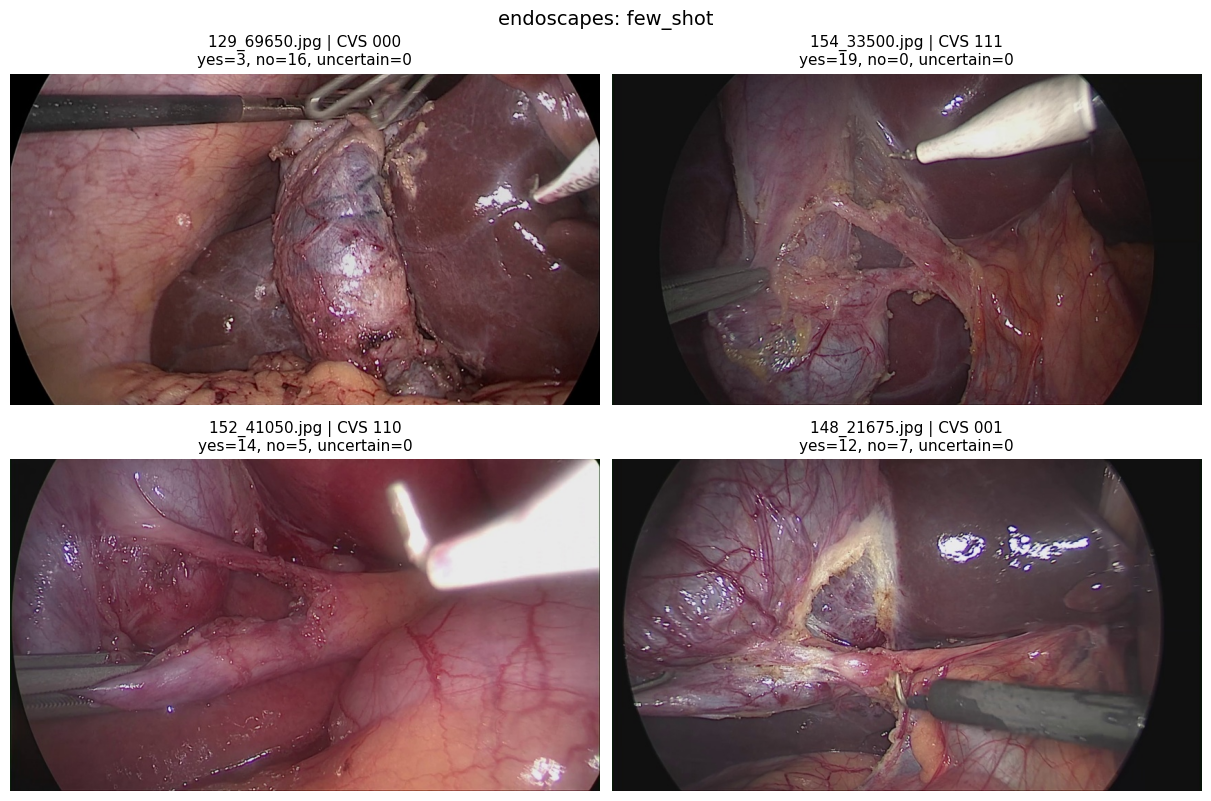

endoscapes/val/129/69650: original CVS={'c1': 0.0, 'c2': 0.0, 'c3': 0.0}; prompt targets={'c1': 0, 'c2': 0, 'c3': 0}
endoscapes/val/154/33500: original CVS={'c1': 1.0, 'c2': 1.0, 'c3': 1.0}; prompt targets={'c1': 1, 'c2': 1, 'c3': 1}
endoscapes/val/152/41050: original CVS={'c1': 1.0, 'c2': 1.0, 'c3': 0.3333333333333333}; prompt targets={'c1': 1, 'c2': 1, 'c3': 0}
endoscapes/val/148/21675: original CVS={'c1': 0.0, 'c2': 0.0, 'c3': 1.0}; prompt targets={'c1': 0, 'c2': 0, 'c3': 1}

All 19 rubric answers (columns follow manifest order):
Check            000         111         110         001
C1-1              no         yes         yes         yes
C1-2              no         yes         yes          no
C1-3              no         yes         yes          no
C1-4              no         yes         yes          no
C1-5              no         yes         yes         yes
C1-6             yes         yes         yes         yes
C2-1              no         yes         yes          no
C2-2 

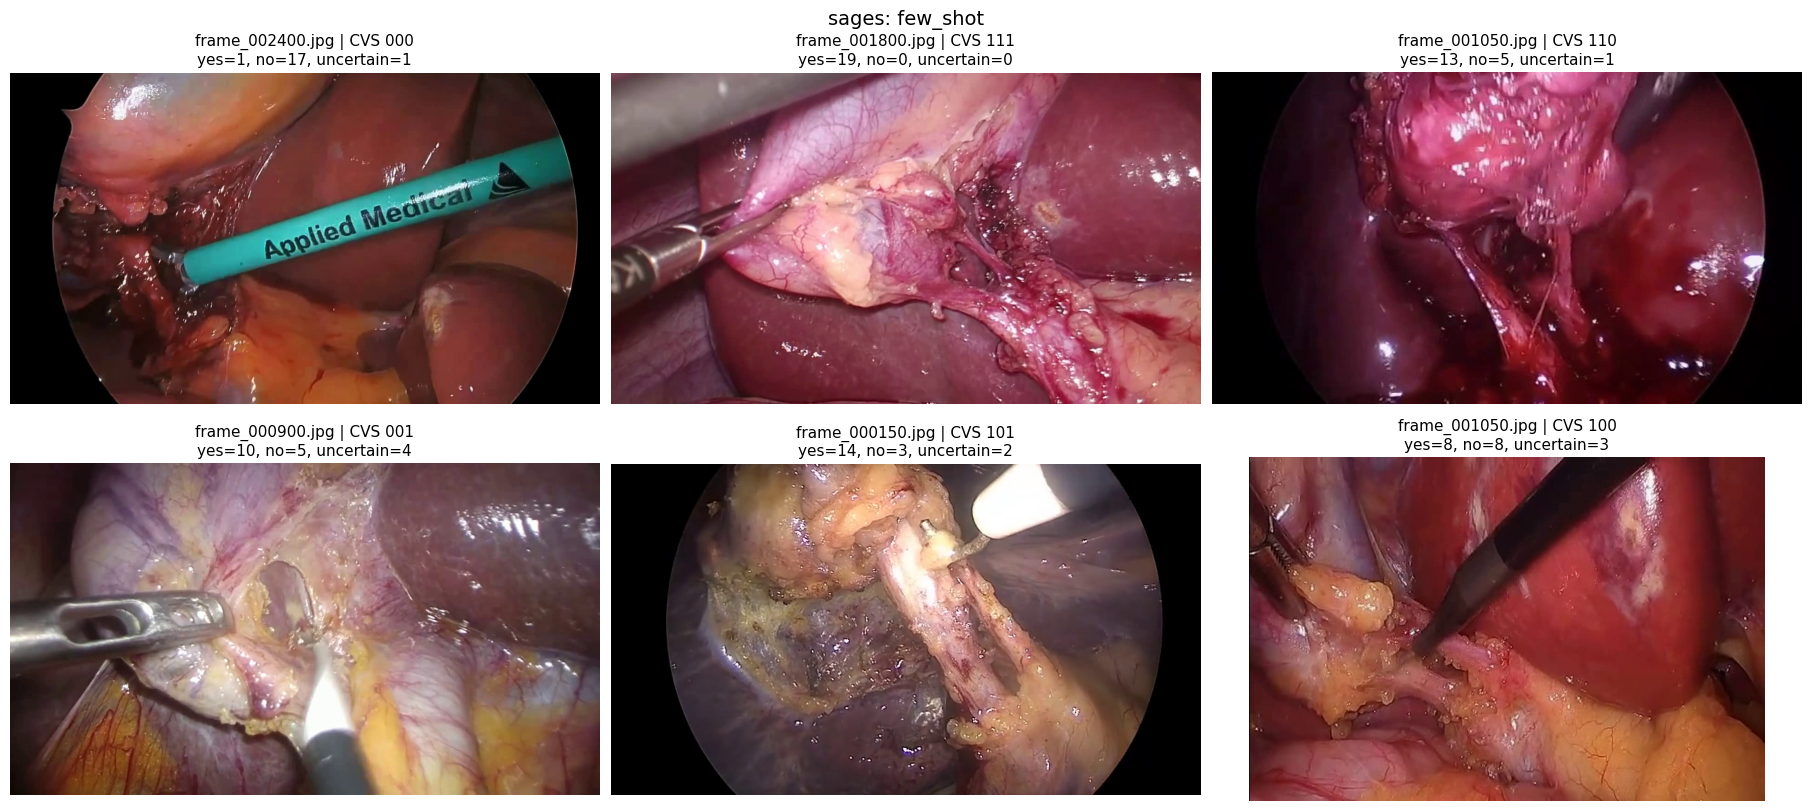

sages/train/24b701a0-f22d-4cba-9871-fab47bd18347/2400: original CVS={'c1': 0.0, 'c2': 0.0, 'c3': 0.0}; prompt targets={'c1': 0, 'c2': 0, 'c3': 0}
sages/train/79b1e745-0fc7-45e0-8159-bcc027cc6db8/1800: original CVS={'c1': 1.0, 'c2': 1.0, 'c3': 1.0}; prompt targets={'c1': 1, 'c2': 1, 'c3': 1}
sages/train/d171f114-19ac-4e30-b24e-ea8015e90bab/1050: original CVS={'c1': 1.0, 'c2': 1.0, 'c3': 0.0}; prompt targets={'c1': 1, 'c2': 1, 'c3': 0}
sages/train/7a208039-f40e-4f03-b73d-555ec9b23119/900: original CVS={'c1': 0.0, 'c2': 0.0, 'c3': 1.0}; prompt targets={'c1': 0, 'c2': 0, 'c3': 1}
sages/train/15c0e57a-97d2-4add-8404-063e3747cd47/150: original CVS={'c1': 1.0, 'c2': 0.0, 'c3': 1.0}; prompt targets={'c1': 1, 'c2': 0, 'c3': 1}
sages/train/3b333490-f68d-4a7c-9e38-14c621da1c85/1050: original CVS={'c1': 1.0, 'c2': 0.0, 'c3': 0.0}; prompt targets={'c1': 1, 'c2': 0, 'c3': 0}

All 19 rubric answers (columns follow manifest order):
Check            000         111         110         001         101  

In [7]:
import hashlib
from PIL import Image as PILImage

selection_paths = {
    "endoscapes": "few_shot_examples/endoscapes/rubrics/filtered/selected_examples_v3.jsonl",
    "sages": "few_shot_examples/cvs_challenge_sages_v1/rubrics/filtered/selected_examples_v5.jsonl",
}

def show_few_shot(source):
    manifest_path = hf_hub_download(
        REPO_ID, selection_paths[source], repo_type="dataset", revision=REVISION, token=False,
    )
    selection = [json.loads(line) for line in Path(manifest_path).read_text().splitlines() if line.strip()]
    few_shot = few_shot_by_source[source]
    assert len(selection) == len(few_shot) == expected_counts[source]["few_shot"]
    columns = 3 if source == "sages" else 2
    fig, axes = plt.subplots(2, columns, figsize=(6 * columns, 8), layout="constrained")
    fig.suptitle(f"{source}: few_shot", fontsize=14)
    for item, row, ax in zip(selection, few_shot, axes.flat):
        assert str(item["video_id"]) == row["video_id"]
        assert item["file_name"] == row["image_filename"]
        image_path = hf_hub_download(
            REPO_ID, item["saved_image"], repo_type="dataset", revision=REVISION, token=False,
        )
        assert hashlib.sha256(Path(image_path).read_bytes()).hexdigest() == row["image_sha256"]
        assert item["rubrics"] == row["rubric_labels"]
        assert item["gt"] == row["cvs_binary_labels"]
        with PILImage.open(image_path) as im:
            ax.imshow(im.copy())
        ax.axis("off")
        counts = answer_counts(item["rubrics"])
        answers = ", ".join(f"{answer}={n}" for answer, n in zip(ANSWERS, counts))
        ax.set_title(f"{item['file_name']} | CVS {item['gt_pattern']}\n{answers}", fontsize=11)
    plt.show()

    for item, row in zip(selection, few_shot):
        print(f"{row['example_id']}: original CVS={row['cvs_labels']}; prompt targets={item['gt']}")
    print("\nAll 19 rubric answers (columns follow manifest order):")
    print(f"{'Check':8s}" + "".join(f"{item['gt_pattern']:>12s}" for item in selection))
    for block in rubrics["criteria"].values():
        for check in block["items"]:
            print(f"{check['id']:8s}" + "".join(f"{item['rubrics'][check['id']]:>12s}" for item in selection))

show_few_shot("endoscapes")
show_few_shot("sages")
